In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_excel('/content/cbc_information (1).xlsx')
df

,ID,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,...,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
0,1,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,...,87.7,26.3,30.1,35.3,11.4,189.0,9.2,12.5,0.17,22.30
1,2,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,...,88.2,25.7,20.2,35.3,11.4,180.0,8.9,12.5,0.16,19.50
2,3,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,...,77.0,22.6,29.5,37.2,13.7,148.0,10.1,14.3,0.14,30.50
3,4,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,3.8,...,77.9,23.2,29.8,46.5,17.0,143.0,8.6,11.3,0.12,16.40
4,5,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,0.4,...,80.6,23.9,29.7,42.7,15.1,236.0,19.5,12.8,0.22,24.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2.7,43.4,7.1,49.5,1.2,0.2,1.3,4.77,13.2,...,86.4,27.4,31.7,37.2,12.2,169.0,10.1,14.3,0.17,28.60
496,497,6.2,35.0,6.9,57.6,2.2,0.4,3.6,4.82,11.6,...,76.7,24.0,31.4,37.2,13.8,177.0,9.9,13.6,0.18,29.00
497,498,8.4,29.2,7.3,63.5,2.0,0.5,4.3,4.40,9.9,...,68.8,22.7,33.0,38.0,10.6,133.1,9.6,12.8,0.12,24.60
498,499,7.4,19.0,8.5,72.5,0.8,0.3,2.9,3.34,7.4,...,70.6,21.9,30.9,36.2,11.0,125.0,10.7,15.9,0.13,33.60


**PRE PROCESSING**

In [3]:
df.isna().sum()

,0
ID,0
WBC,0
LYMp,0
MIDp,0
NEUTp,0
LYMn,0
MIDn,0
NEUTn,0
RBC,0
HGB,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# 1. Smart Medical Indicators Addition Function
def add_medical_features(data):
    data['Mentzer_Index'] = data['MCV'] / data['RBC']
    data['Shine_Lal'] = (data['MCV']**2 * data['MCH']) / 100
    return data

# 2. Reference classification function (Expert Rules)
def categorize_expert(row):
    m = row['MCV'] / row['RBC']
    if row['HGB'] < 8.0:
        return 'Beta-Thalassemia Major' if row['MCV'] < 70 else 'Alpha-Thalassemia Major'
    if row['MCV'] >= 81 and row['HGB'] > 12.0:
        return 'Normal'
    if m < 13 or row['MCV'] < 81:
        return 'Beta-Thalassemia Minor' if row['MCV'] < 72 else 'Alpha-Thalassemia Minor'
    return 'Normal'

df['Target_Label'] = df.apply(categorize_expert, axis=1)
df = add_medical_features(df)

In [6]:
df['Target_Label'].value_counts()

,count
Target_Label,
Normal,290
Alpha-Thalassemia Minor,117
Beta-Thalassemia Minor,60
Alpha-Thalassemia Major,19
Beta-Thalassemia Major,14


In [7]:
seeds = []
for _ in range(150):
    seeds.append([13.8, 80.0, 26.5, 5.1, 'Alpha-Thalassemia Minor'])
    seeds.append([11.8, 71.0, 23.0, 5.4, 'Beta-Thalassemia Minor'])
    seeds.append([7.0, 74.0, 24.0, 3.8, 'Alpha-Thalassemia Major'])
    seeds.append([5.8, 56.0, 17.0, 3.1, 'Beta-Thalassemia Major'])

seed_df = pd.DataFrame(seeds, columns=['HGB', 'MCV', 'MCH', 'RBC', 'Target_Label'])
seed_df = add_medical_features(seed_df)
df = pd.concat([df, seed_df], ignore_index=True)

In [8]:
df['Target_Label'].value_counts()

,count
Target_Label,
Normal,290
Alpha-Thalassemia Minor,267
Beta-Thalassemia Minor,210
Alpha-Thalassemia Major,169
Beta-Thalassemia Major,164


In [9]:
df.head()

,ID,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,...,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR,Target_Label,Mentzer_Index,Shine_Lal
0,1.0,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,...,35.3,11.4,189.0,9.2,12.5,0.17,22.3,Alpha-Thalassemia Major,31.660650,2022.80927
1,2.0,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,...,35.3,11.4,180.0,8.9,12.5,0.16,19.5,Alpha-Thalassemia Major,31.056338,1999.26468
2,3.0,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,...,37.2,13.7,148.0,10.1,14.3,0.14,30.5,Alpha-Thalassemia Minor,19.395466,1339.95400
3,4.0,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,3.8,...,46.5,17.0,143.0,8.6,11.3,0.12,16.4,Alpha-Thalassemia Major,18.459716,1407.87112
4,5.0,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,0.4,...,42.7,15.1,236.0,19.5,12.8,0.22,24.8,Alpha-Thalassemia Major,20.508906,1552.63004


**ENCODING**

In [10]:
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df['Target_Label'])



**TRAINING,TESTING DATA**

In [11]:
X = df[['MCV', 'MCH', 'HGB', 'RBC', 'Mentzer_Index', 'Shine_Lal']]
y = df['Target_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
sm = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

**SMOTE**

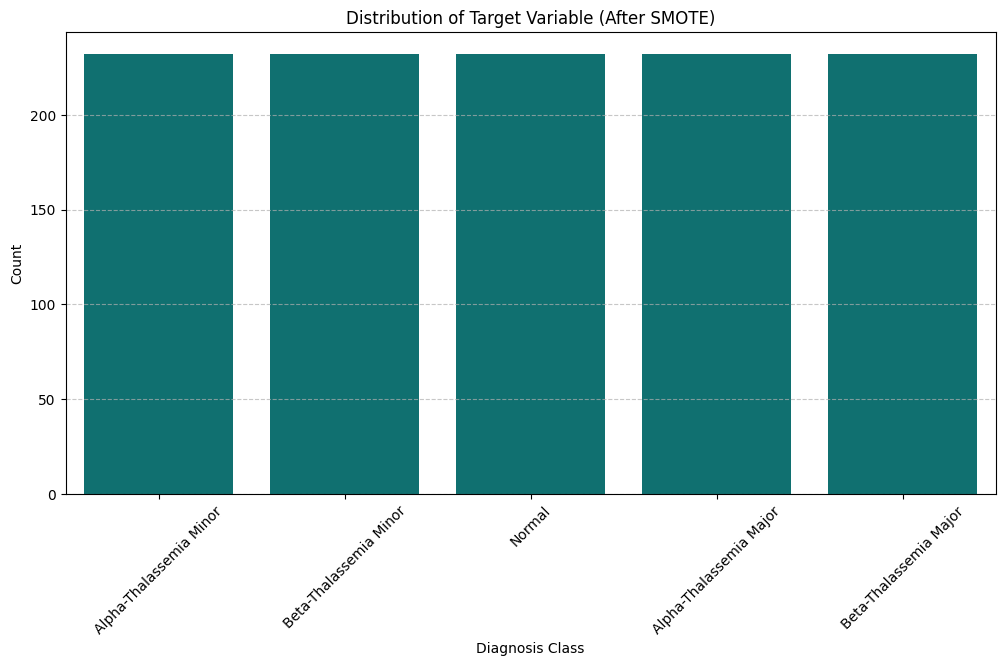

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
y_names = le.inverse_transform(y_train_res)

plt.figure(figsize=(12, 6))
sns.countplot(x=y_names, color='teal')

plt.title('Distribution of Target Variable (After SMOTE)')
plt.xlabel('Diagnosis Class')
plt.ylabel('Count')
plt.xticks(rotation=45) # تدوير الأسماء عشان متدخلش في بعضها
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**RANDOM FOREST**

In [14]:
from sklearn.metrics import classification_report, accuracy_score
rf_model = RandomForestClassifier(n_estimators=1000, class_weight='balanced', random_state=42)
rf_model.fit(X_train_res, y_train_res)

print(f"accuracy: {accuracy_score(y_test, rf_model.predict(X_test))*100:.2f}%")
y_pred = rf_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

accuracy=accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

accuracy: 99.55%

Classification Report:
                          precision    recall  f1-score   support

Alpha-Thalassemia Major       1.00      1.00      1.00        34
Alpha-Thalassemia Minor       0.98      1.00      0.99        53
 Beta-Thalassemia Major       1.00      1.00      1.00        33
 Beta-Thalassemia Minor       1.00      1.00      1.00        42
                 Normal       1.00      0.98      0.99        58

               accuracy                           1.00       220
              macro avg       1.00      1.00      1.00       220
           weighted avg       1.00      1.00      1.00       220

Accuracy: 99.55%


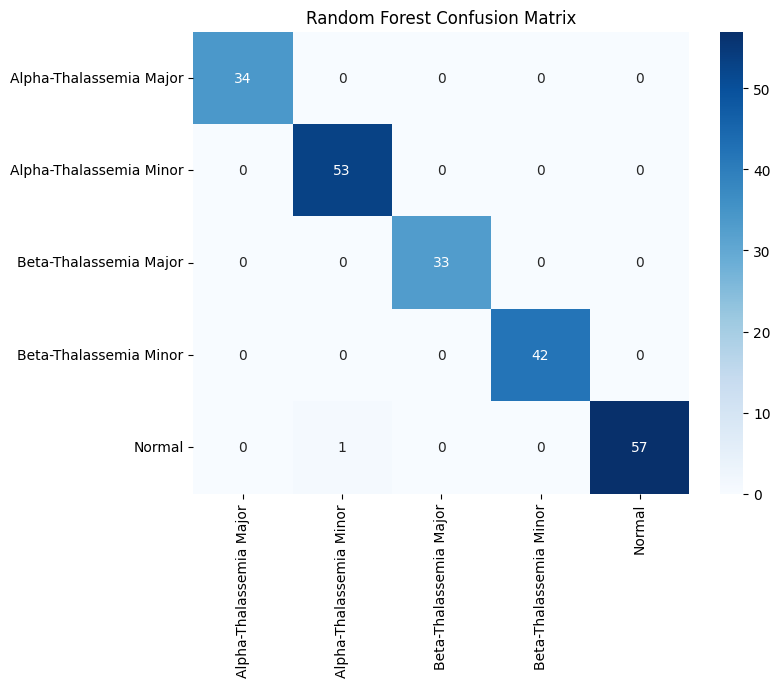

In [15]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.show()

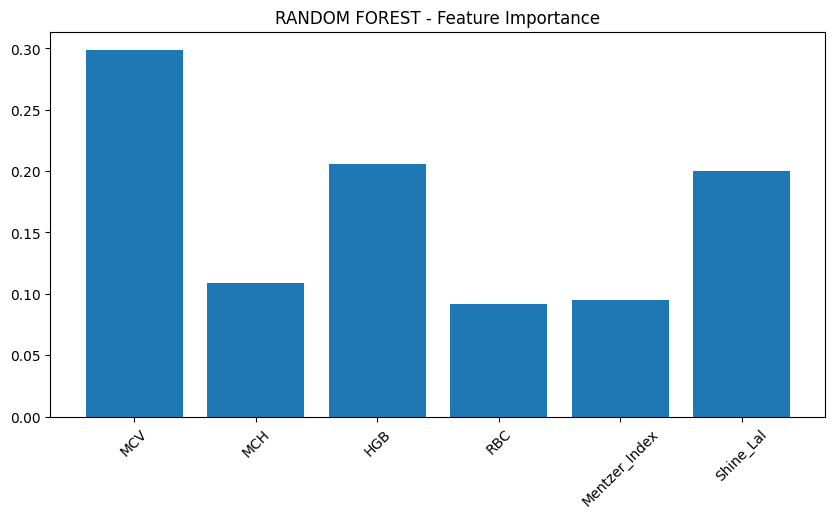

In [16]:
plt.figure(figsize=(10,5))
plt.bar(X.columns, rf_model.feature_importances_)
plt.title('RANDOM FOREST - Feature Importance')
plt.xticks(rotation=45)
plt.show()

**DECISION TREE**

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)
dt_model.fit(X_train_res, y_train_res)

y_pred_dt = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f" Accuracy: {dt_acc*100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))



 Accuracy: 100.00%

--- Classification Report ---
                         precision    recall  f1-score   support

Alpha-Thalassemia Major       1.00      1.00      1.00        34
Alpha-Thalassemia Minor       1.00      1.00      1.00        53
 Beta-Thalassemia Major       1.00      1.00      1.00        33
 Beta-Thalassemia Minor       1.00      1.00      1.00        42
                 Normal       1.00      1.00      1.00        58

               accuracy                           1.00       220
              macro avg       1.00      1.00      1.00       220
           weighted avg       1.00      1.00      1.00       220



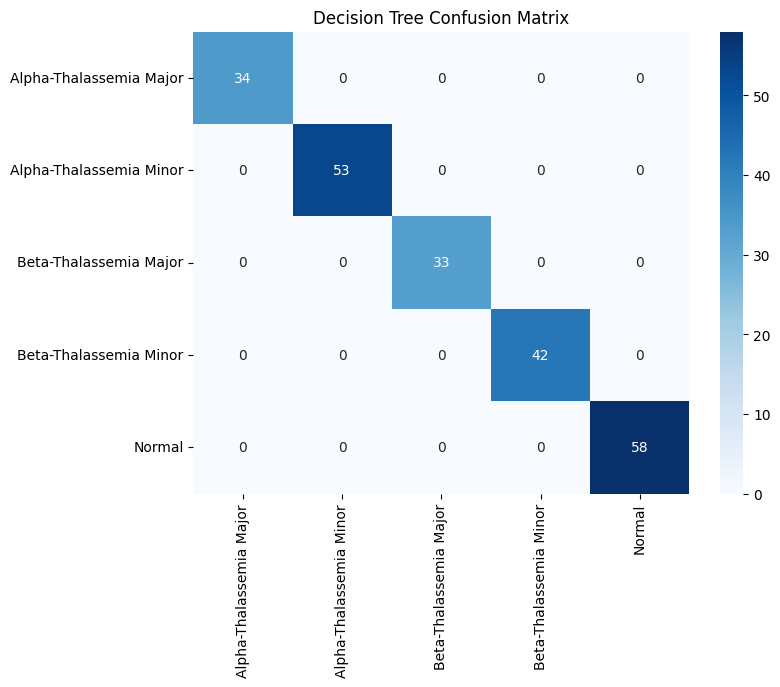

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.show()

**XGBOOST**

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    random_state=42
)
xgb_model.fit(X_train_res, y_train_res)

y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy: {xgb_acc*100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))



Accuracy: 99.55%

--- Classification Report ---
                         precision    recall  f1-score   support

Alpha-Thalassemia Major       1.00      1.00      1.00        34
Alpha-Thalassemia Minor       1.00      1.00      1.00        53
 Beta-Thalassemia Major       1.00      0.97      0.98        33
 Beta-Thalassemia Minor       0.98      1.00      0.99        42
                 Normal       1.00      1.00      1.00        58

               accuracy                           1.00       220
              macro avg       1.00      0.99      0.99       220
           weighted avg       1.00      1.00      1.00       220



In [ ]:
def take_input():
    features = {}
    features['HGB'] = float(input("1. Enter HGB (g/dL): "))
    features['MCV'] = float(input("2. Enter MCV (fL): "))
    features['MCH'] = float(input("3. Enter MCH (pg): "))
    features['RBC'] = float(input("4. Enter RBC (10^12/L): "))
    return features

def predict(rf_model, features, le):
    h, m, mh, r = features['HGB'], features['MCV'], features['MCH'], features['RBC']
    mentzer = m / r
    shine = (m**2 * mh) / 100

    feature_values = pd.DataFrame([[m, mh, h, r, mentzer, shine]],
                                 columns=['MCV', 'MCH', 'HGB', 'RBC', 'Mentzer_Index', 'Shine_Lal'])

    prediction_idx = rf_model.predict(feature_values)[0]

    condition_name = le.inverse_transform([prediction_idx])[0]
    return condition_name


try:
    user_input = take_input()

    thalassemia_condition = predict(rf_model, user_input, le)

    print("-" * 30)
    print(f" The predicted condition is: {thalassemia_condition}")
    print("-" * 30)
except Exception as e:
    print(f" error: {e}")

1. Enter HGB (g/dL): 14
2. Enter MCV (fL): 80.7
3. Enter MCH (pg): 98.3
4. Enter RBC (10^12/L): 1
------------------------------
 The predicted condition is: Alpha-Thalassemia Minor
------------------------------


In [20]:
import joblib
joblib.dump(rf_model, 'thalassemia_expert_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [22]:
import joblib
import pandas as pd

model = joblib.load('thalassemia_expert_model.pkl')
le = joblib.load('label_encoder.pkl')

# 2. دالة التنبؤ السريع
def fast_predict(hgb, mcv, mch, rbc):
    m_index = mcv / rbc
    s_lal = (mcv**2 * mch) / 100
    features = pd.DataFrame([[mcv, mch, hgb, rbc, m_index, s_lal]],
                           columns=['MCV', 'MCH', 'HGB', 'RBC', 'Mentzer_Index', 'Shine_Lal'])

    pred = model.predict(features)[0]
    return le.inverse_transform([pred])[0]

print(f"Result from saved model: {fast_predict(11.5, 67, 22.4, 5.2)}")

Result from saved model: Beta-Thalassemia Minor
